# Omega60 laser sampling

In [727]:
import matplotlib.pyplot as plt
import scipy as sp
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import uniform
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
import pyvista as pv
from scipy.stats import norm
import scipy.stats as stats 


## Support functions

### Conversion

In [728]:
def cart_to_sph(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    # On utilise np.clip pour s'assurer que la valeur est bien entre -1 et 1
    # Cela évite les NaN si z/r dépasse 1 à cause de la précision flottante
    theta = np.arccos(np.clip(z / r, -1.0, 1.0))
    # On s'assure que phi reste bien dans l'intervalle [0, 2*pi]
    phi = np.mod(np.pi + np.arctan2(y, x), 2 * np.pi)
    return np.array([r, theta, phi])

def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])


### Spherical function plotter

In [729]:
def plot_spherical_function(theta, phi, f, name='f', title="Spherical Function"):
  f_flat = f.ravel()

  xs, ys, zs = sph_to_cart(1.0, theta, phi)
  points = np.column_stack((xs.ravel(), ys.ravel(), zs.ravel()))
  f_flat = f.ravel()

  cloud = pv.PolyData(points)
  cloud[name] = f_flat

  plotter = pv.Plotter()
  plotter.add_mesh(cloud, render_points_as_spheres=True, point_size=10, scalars=name, cmap='plasma')
  plotter.add_scalar_bar(title=name, vertical=True)

  return plotter

### Plotter of sectors given theta and phi

In [730]:
def plot_spherical_sectors( theta, phi, fs, name='func', title="Spherical Sectors" ):
  """
    Interpolates spherical data (theta, phi, intensity) onto a 3D sphere mesh 
    and visualizes the distribution using PyVista.
    """
  func = sp.interpolate.RegularGridInterpolator( (theta, phi), fs, method='nearest', bounds_error=False, fill_value=0.0 )

  sphere = pv.Sphere( theta_resolution=100, phi_resolution=100 )
  r, ts, ps = cart_to_sph( sphere.points[:,0], sphere.points[:,1], sphere.points[:,2] )
  sphere['Data'] = func( ( ts, ps, ) )

  plotter = pv.Plotter()
  plotter.add_mesh(sphere, scalar_bar_args={'title': 'Z Position'})
  
  return plotter

### Sample of random laser points in a 2D window distribution normale

In [731]:
def sample_window( t1, t2, l1=1., l2=1., center=np.array([ 0., 0., 0., ]), num_points=1000, dist = lambda num_points: sp.stats.uniform.rvs( loc=-1.0, scale=2.0, size=( num_points, 2, ) ), ):
  """
    Generates a set of random starting points (sampling) within a 2D rectangular 
    laser window defined by vectors t1 and t2 in 3D space.
    """
  sample = np.zeros( (num_points, 2,) )
  k = 0
  while k < num_points:
    s = dist(1)
    if np.abs(s[0,0]) <= 1.0 and np.abs(s[0,1]) <= 1.0:
      sample[k,:] = s[0,:]
      k += 1
  # map to the window
  v1 = 0.5 * l1 * t1 / np.linalg.norm( t1 )
  v2 = 0.5 * l2 * t2 / np.linalg.norm( t2 )
  return center + sample[:,0,None] * v1 + sample[:,1,None] * v2

In [732]:
t1 = np.array([ 0., 1., 0., ]) # ey
t2 = np.array([ 0., 0., 1., ]) # ez

xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=1000, )

focus = np.array([ 1., 0., 0., ])
us = focus - xs
us = us / np.linalg.norm( us, axis=1 )[:,None]

print(xs.shape)

(1000, 3)


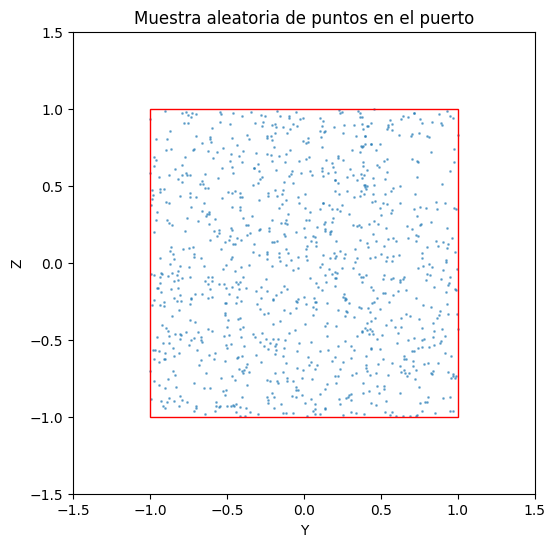

In [733]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

### Use of normal distribution in the sample of points distribution Gaussienne

In [734]:
dist = lambda num_points: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(num_points, 2))
xs = sample_window( t1, t2, l1=2., l2=2., center=np.array([ 0., 0., 0., ]), num_points=10000, dist=dist )
print(xs.shape  )

(10000, 3)


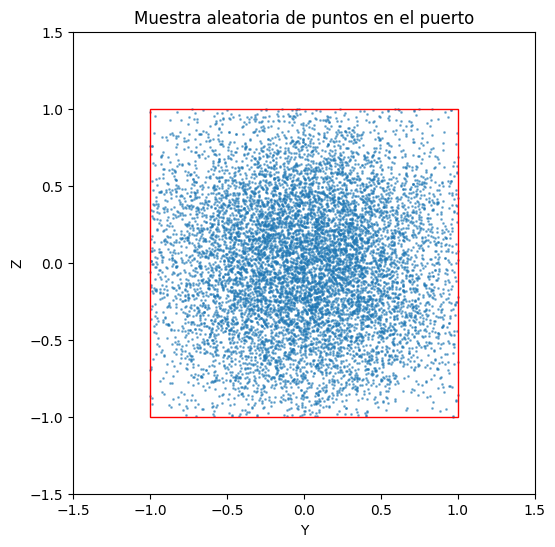

In [735]:
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter( xs[:,1], xs[:,2], s=1, alpha=0.5 )

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

ax.set_title("Muestra aleatoria de puntos en el puerto")
ax.set_xlabel("Y")
ax.set_ylabel("Z")

rect = plt.Rectangle( (-1,-1), 2, 2, linewidth=1, edgecolor='r', facecolor='none' )
ax.add_patch(rect)

## Chamber and target geometry parameters

In [736]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.000605 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Define geometry and focal distances

### Define and create beams based on Omega 60 

In [737]:
def get_omega_dataframe():
    """
    Constructs the master database for OMEGA-60 laser parameters.
    Calculates local coordinate systems (tangent and normal vectors) for each beam,
    ensuring compatibility with ARWEN simulation requirements.
    """
    # --- 1. Physical Configuration ---
    DEFAULT_ENERGY = 500.0     # Default beam energy [Joules]
    WAVELENGTH = 351e-9        # UV laser wavelength [351 nm]

    # OMEGA-60 port configuration: (Theta_deg, Beam_Count, Phi_Offset_deg)
    # Based on the standard 60-beam direct-drive geometry.
    omega_config = [
        (23.2, 6, 0), (47.8, 12, 15), (59.1, 12, 0),   # Northern Hemisphere
        (120.9, 12, 0), (132.2, 12, 15), (156.8, 6, 0) # Southern Hemisphere
    ]

    all_data = []
    beam_count = 1

    for theta_deg, num_beams, phi_offset in omega_config:
        # Uniform azimuthal distribution over 360°
        phis_deg = np.linspace(0, 360, num_beams, endpoint=False) + phi_offset
        
        for phi_deg in phis_deg:
            # --- 2. Geometric Coordinate Transformation ---
            # Conversion to radians for NumPy trigonometric functions
            theta_rad = np.deg2rad(theta_deg)
            phi_rad = np.deg2rad(phi_deg % 360)
            
            # Unit normal vector (beam propagation direction)
            # In a center-aligned sphere, the normal is the radial vector
            nx = np.sin(theta_rad) * np.cos(phi_rad)
            ny = np.sin(theta_rad) * np.sin(phi_rad)
            nz = np.cos(theta_rad)
            normal_u = np.array([nx, ny, nz])
            
            # Position of the port center on the chamber wall
            center = normal_u * CHAMBER_RADIUS

            # --- 3. Local Tangent Basis Calculation (t1, t2) ---
            # t1: Azimuthal direction vector (East-West alignment)
            t1 = np.array([-np.sin(phi_rad), np.cos(phi_rad), 0.0])
            
            # Singularity handling at the poles (if t1 is null)
            if np.linalg.norm(t1) < 1e-6: 
                t1 = np.array([1, 0, 0])
            t1 /= np.linalg.norm(t1)
            
            # t2: Polar direction vector (North-South alignment) via cross product
            # Completes the orthogonal right-handed coordinate system (t1, t2, normal)
            t2 = np.cross(normal_u, t1)
            t2 /= np.linalg.norm(t2)

            # --- 4. Data Record Assembly (Standardized Format) ---
            all_data.append({
                'port': f'OMEGA_J{beam_count:02d}',
                'subwindow': 0,              # Specific to OMEGA (unlike NIF quads)
                'LAT_rad': theta_rad,        # Latitude (Theta) in radians
                'LONG_rad': phi_rad,         # Longitude (Phi) in radians
                'color': 'blue' if theta_deg < 90 else 'red',
                'energy': DEFAULT_ENERGY,
                'wavelength': WAVELENGTH,
                'center': center,            # Numpy array [x, y, z]
                'normal': normal_u,          # Numpy unit vector [nx, ny, nz]
                't1': t1,                    # First tangent vector
                't2': t2,                    # Second tangent vector
                'beam_radius': BEAM_RADIUS,
                'focus': None                # Placeholder for focusing parameters
            })
            beam_count += 1

    return pd.DataFrame(all_data)

# --- EXECUTION ---
df_omega = get_omega_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,None
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,None
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,None
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,None
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,None


### Define focal point

In [738]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calculates the focal distance required to achieve a specific beam spot size.
    A positive defocus (in mm) shifts the focal point beyond the target center, 
    widening the irradiation area to improve illumination uniformity.
    """
    # Convert defocus from mm to meters and calculate the effective target radius
    # This accounts for the beam divergence/convergence at the target surface.
    effective_target_radius = TARGET_RADIUS + (defocus_mm / 1000.0) 
    
    # Using Thales' theorem (intercept theorem) to determine the focal length (f_window)
    # relative to the chamber geometry and beam aperture.
    f_window = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - effective_target_radius)
    return f_window

def compute_focus_position(port_center, f_window):
    """
    Computes the 3D coordinates of the focal point along the beam's optical axis.
    """
    # Normal unit vector pointing from the port center toward the chamber origin (0,0,0)
    propagation_vector = port_center / np.linalg.norm(port_center)
    
    # Position the focal point along the optical axis at distance f_window
    focal_point_pos = port_center - (propagation_vector * f_window)
    return focal_point_pos

def assign_beam_focus(beam_row):
    """
    Helper function to apply a standardized defocus to a specific beam port.
    A 2.0mm defocus is typically used to over-fill the target and reduce intensity peaks.
    """
    f_dist = compute_focal_distance(defocus_mm=2) 
    return compute_focus_position(beam_row["center"], f_dist)


# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = get_omega_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,"[-0.005693642505419816, 0.0, -0.01328426325914..."
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,"[-0.002846821252709908, -0.004930839049760438,..."
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,"[0.002846821252709908, -0.004930839049760438, ..."
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,"[0.005693642505419816, -6.972701069751618e-19,..."
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,"[0.0028468212527099634, 0.004930839049760438, ..."


### Creates data frame of complete beam geometry and data

In [739]:
# 1. We use the 'df_omega' DataFrame we just created and filled with focus data
# No need to create a new DataFrame from a list anymore!

# 2. Define OMEGA beam dimensions
# For OMEGA, the beam diameter is typically 28cm (0.28m)
df_omega['l1'] = 0.28
df_omega['l2'] = 0.28

# 3. Function to split vector columns [x, y, z] into three separate columns
def expand_vector_column(df, column_name):
    # Create a temporary DataFrame from the list of coordinates
    # .tolist() is used because these columns contain numpy arrays
    temp = pd.DataFrame(df[column_name].tolist(), index=df.index)
    temp.columns = [f'{column_name}_x', f'{column_name}_y', f'{column_name}_z']
    return temp

# 4. Expand all geometric vector columns
# This "flattens" the data so ARWEN can read it easily
df_centers = expand_vector_column(df_omega, 'center')
df_t1      = expand_vector_column(df_omega, 't1')
df_t2      = expand_vector_column(df_omega, 't2')
df_normal  = expand_vector_column(df_omega, 'normal')
df_focus   = expand_vector_column(df_omega, 'focus')

# 5. Assemble the final Master Table
# We select the metadata and join it with the expanded coordinates
data_columns = ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_omega_final = pd.concat([
    df_omega[data_columns],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Aesthetic renaming for clarity
df_omega_final = df_omega_final.rename(columns={'LAT_rad': 'LAT', 'LONG_rad': 'LONG'})

# 7. Display the result
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,0.28,0.28,0.650004,...,0.0,-0.919135,-0.000000e+00,0.393942,0.393942,0.000000e+00,0.919135,-0.005694,0.000000e+00,-0.013284
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,-7.959946e-01,0.393942,0.196971,3.411637e-01,0.919135,-0.002847,-4.930839e-03,-0.013284
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,-7.959946e-01,0.393942,-0.196971,3.411637e-01,0.919135,0.002847,-4.930839e-03,-0.013284
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,0.28,0.28,-0.650004,...,0.0,0.919135,-1.125616e-16,0.393942,-0.393942,4.824397e-17,0.919135,0.005694,-6.972701e-19,-0.013284
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,7.959946e-01,0.393942,-0.196971,-3.411637e-01,0.919135,0.002847,4.930839e-03,-0.013284
5,OMEGA_J06,0,0.404916,5.235988,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,7.959946e-01,0.393942,0.196971,-3.411637e-01,0.919135,-0.002847,4.930839e-03,-0.013284
6,OMEGA_J07,0,0.834267,0.261799,blue,500.0,3.510000e-07,0.28,0.28,1.180678,...,0.0,-0.648832,-1.738541e-01,0.740805,0.715562,1.917343e-01,0.671721,-0.010342,-2.771136e-03,-0.009708
7,OMEGA_J08,0,0.834267,0.785398,blue,500.0,3.510000e-07,0.28,0.28,0.864316,...,0.0,-0.474978,-4.749782e-01,0.740805,0.523828,5.238280e-01,0.671721,-0.007571,-7.570886e-03,-0.009708
8,OMEGA_J09,0,0.834267,1.308997,blue,500.0,3.510000e-07,0.28,0.28,0.316362,...,0.0,-0.173854,-6.488323e-01,0.740805,0.191734,7.155623e-01,0.671721,-0.002771,-1.034202e-02,-0.009708
9,OMEGA_J10,0,0.834267,1.832596,blue,500.0,3.510000e-07,0.28,0.28,-0.316362,...,0.0,0.173854,-6.488323e-01,0.740805,-0.191734,7.155623e-01,0.671721,0.002771,-1.034202e-02,-0.009708


## Impacts of the laser beams from window to a target sphere

### Calculates hits on sphere

In [740]:
def hit_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Calculates the intersection distance(s) 'l' between a ray (origin x, direction u) 
    and a sphere using the quadratic formula.
    """
  
    dx = x - center

    A = u[0]**2 + u[1]**2 + u[2]**2 
    B = 2*(dx[0]*u[0] + dx[1]*u[1] + dx[2]*u[2])
    C = dx[0]**2 + dx[1]**2 + dx[2]**2 - radius**2

    # Discriminant calculation
    disc = B*B - 4*A*C

    # Calculate intersection points (if they exist)
    if disc < 0:
        # No intersection: the ray misses the sphere
        return []
    elif disc == 0:
        # One intersection: the ray is tangent to the sphere
        return [ -0.5 * B / A ] 
    else:
        # Two intersections: the ray enters and exits the sphere
        disc = np.sqrt(disc)
        l1 = 0.5 * (-B + disc) / A
        l2 = 0.5 * (-B - disc) / A
        return [ l1, l2, ]

### Collects impact information

In [741]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Determines the nearest valid intersection distance (l) between a ray 
    and the sphere surface, filtering out negative or non-existent results.
    """
    ls = hit_sphere( x, u, radius=radius, center=center, )
    
    if len(ls) == 0:
        return -1.
    elif len(ls) == 1:
        if ls[0] < 0:
            return -1.
        else:
            return ls[0]
    else:
        l1, l2 = ls
        if l1 < 0 and l2 < 0:
            return -1.
        elif l1 > 0 and l2 > 0:
            return min(l1, l2)
        else:
            return max(l1, l2)

def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Aggregates all physical properties of a ray's impact, calculating the 3D 
    position, surface normal, incidence cosine (cs), and spherical mapping.
    """
    l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) # Impact length
    xsph = x + l * u 
    n = ( xsph - center ) / np.linalg.norm( xsph - center )
    cs = np.dot( n, u) / np.linalg.norm(u)
    return [ x, u, l, xsph, cs, cart_to_sph( xsph[0], xsph[1], xsph[2] ), n, ]

### Validation of hits on sphere

In [742]:
def ray_hit_on_sphere( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Determines the nearest valid intersection distance (l) between a ray 
    and the sphere surface, filtering out negative or non-existent results.
    """
    # Get all potential intersection distances from the geometric solver
    ls = hit_sphere( x, u, radius=radius, center=center, )
    
    if len(ls) == 0:
        # Case 1: No intersection at all
        return -1.
    elif len(ls) == 1:
        # Case 2: Tangent intersection
        if ls[0] < 0:
            return -1. # Intersection is behind the ray origin
        else:
            return ls[0]
    else:
        # Case 3: Two intersections (entry and exit points)
        l1, l2 = ls
        if l1 < 0 and l2 < 0:
            return -1. # Both points are behind the ray origin
        elif l1 > 0 and l2 > 0:
            return min(l1, l2) # Return the closest point (entry point)
        else:
            return max(l1, l2) # One point is behind, return the forward one

def ray_hit( x, u, radius, center=np.array([0.,0.,0.,]), ):
    """
    Aggregates all physical properties of a ray's impact, calculating the 3D 
    position, surface normal, incidence cosine (cs), and spherical mapping.
    """
    # Calculate the valid impact length (distance)
    l = ray_hit_on_sphere( x, u, radius=radius, center=center, ) 
    
    # Calculate the 3D coordinates of the impact point on the sphere surface
    xsph = x + l * u 
    
    # Calculate the unit normal vector at the impact point
    n = ( xsph - center ) / np.linalg.norm( xsph - center )
    
    # Calculate the cosine of the incidence angle (Cross Section weight)
    # This represents how "squarely" the ray hits the surface
    cs = np.dot( n, u) / np.linalg.norm(u)
    
    # Return a comprehensive list: origin, direction, distance, impact point, 
    # incidence cosine, spherical coordinates (r, theta, phi), and the normal vector.
    return [ 
        x, u, l, xsph, cs, 
        cart_to_sph( xsph[0], xsph[1], xsph[2] ), 
        n 
    ]

## Simulation of impacts for 1 beam

### Creates beam sample

In [743]:
def beam_sample(beam, num_samples):
    """
    Prepares and executes the sampling of a specific laser beam by reconstructing 
    its geometric vectors and defining its energy distribution profile.
    """
    
    # 1. Reconstruct vectors from individual coordinate columns (x, y, z)
    # These vectors define the orientation and position of the laser's starting window.
    t1 = np.array([beam['t1_x'], beam['t1_y'], beam['t1_z']])
    t2 = np.array([beam['t2_x'], beam['t2_y'], beam['t2_z']])
    center = np.array([beam['center_x'], beam['center_y'], beam['center_z']])
    
    l1 = beam['l1']
    l2 = beam['l2']
    
    # 2. Define the NORMAL (Gaussian) distribution
    # loc=0.0: Centered on the beam axis.
    # scale=0.5: Standard deviation (concentrates ~95% of energy within the central area).
    # IMPORTANT: The lambda function generates numerical data using .rvs to ensure compatibility.
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.5).rvs(size=(n, 2))
    
    # Map the distribution to the 3D window coordinates
    return sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)

### Creates hit of beam on sphere

In [744]:
def beam_hit(beam, num_samples, radius, center_target):
    """
    Simulates a full laser beam by sampling multiple rays and calculating their 
    impacts on a target sphere.
    
    This function generates ray origins based on a Gaussian distribution, computes 
    their trajectories toward a focal point, and collects physical impact data 
    (position, distance, normal vector, and incidence cosine) for rays that 
    successfully hit the target.
    """
    data = []
    
    # 1. Extract beam geometric parameters and vectors
    t1, t2 = beam['t1'], beam['t2']
    center, focus = beam['center'], beam['focus']
    l1, l2 = beam['l1'], beam['l2']
    
    # 2. Define a Gaussian spatial distribution for the ray sampling
    # scale=0.15 defines the beam's concentration (narrowness)
    dist_gauss = lambda n: sp.stats.norm(loc=0.0, scale=0.15).rvs(size=(n, 2))
    
    # 3. Generate the starting positions (origins) for all rays in the beam window
    ray_origins = sample_window(t1, t2, l1=l1, l2=l2, center=center, num_points=num_samples, dist=dist_gauss)
    
    # 4. Iterate through each ray to calculate its trajectory and impact
    for i in range(num_samples):
        x_ray = ray_origins[i]
        
        # Calculate the unit direction vector pointing from the origin toward the focus
        u_ray = (focus - x_ray) / np.linalg.norm(focus - x_ray)
        
        # Calculate detailed intersection data with the target sphere
        resultat_complet = ray_hit(x_ray, u_ray, radius, center_target)
        
        l_impact = resultat_complet[2]
        
        # 5. Only store data if the ray actually hits the sphere (positive distance)
        if l_impact > 0: 
            data.append({
                'port': beam['port'],
                'x': resultat_complet[0],       # Origin
                'u': resultat_complet[1],       # Direction
                'l': l_impact,                  # Impact distance
                'xsph': resultat_complet[3],    # Impact point (Cartesian)
                'cs': resultat_complet[4],      # Incidence cosine (Cross Section)
                'sph': resultat_complet[5],     # Impact point (Spherical: r, theta, phi)
                'n': resultat_complet[6]        # Surface normal at impact
            })
            
    # Return the results as a structured DataFrame for further analysis (e.g., ARWEN)
    return pd.DataFrame(data)

### Simulation parameters

In [745]:
# 1. Prepare the row to match the format expected by beam_hit
row = df_omega.iloc[0].copy()

# Create the vectors that the beam_hit function will look for

# 2. Now launch the function with this "prepared" row
impacts_1window = beam_hit(
    row, 
    num_samples=10000, 
    radius=TARGET_RADIUS, 
    center_target=np.array([0.0, 0.0, 0.0])
)

print(f"Effective impacts: {len(impacts_1window)} out of 10000 launched rays.")

Effective impacts: 9960 out of 10000 launched rays.


### Impacts data

In [746]:
impacts_1window.head()

,port,x,u,l,xsph,cs,sph,n
0,OMEGA_J01,"[0.6647632912022444, -0.027117899738994814, 1....","[-0.40273698438770195, 0.016289459642717056, -...",1.649761,"[0.0003433867251859679, -0.0002441790742495793...",-0.891892,"[0.0006049999996103402, 0.7704389303966312, 2....","[0.5675813643093084, -0.40360177587908547, 0.7..."
1,OMEGA_J01,"[0.6478404555763402, -0.024797209520374806, 1....","[-0.39259800635904757, 0.014896445418137632, -...",1.649623,"[0.00020176920069758797, -0.000223691096936724...",-0.933927,"[0.000605000000799116, 0.521205034777442, 2.30...","[0.3335028106298852, -0.3697373498202662, 0.86..."
2,OMEGA_J01,"[0.6306294511147015, -0.0026824032524315746, 1...","[-0.3822704784763799, 0.0016114511402375278, -...",1.649561,"[5.1119757156325996e-05, -2.4216894109425468e-...",-0.952366,"[0.00060500000018136, 0.09363391758741689, 2.6...","[0.08449546634876347, -0.04002792413581158, 0...."
3,OMEGA_J01,"[0.6439268204783029, -0.009143765861991622, 1....","[-0.39028169327173606, 0.005493429820710257, -...",1.649442,"[0.00017997265540681262, -8.26743688882043e-05...",-0.986799,"[0.0006049999999466299, 0.33350957951534016, 2...","[0.29747546350857673, -0.13665184941404532, 0...."
4,OMEGA_J01,"[0.6547026703257499, 0.0029148517250398302, 1....","[-0.3967622910201964, -0.001751226083399764, -...",1.649408,"[0.000279910664692129, 2.6366019046761453e-05,...",-0.996427,"[0.0006049999999462002, 0.48330732876816523, 3...","[0.46266225573061176, 0.04358019677538191, 0.8..."


### Impacts of data organized

In [747]:
def expand_impacts(df_impacts):
    """
    Final version for ARWEN: expands all vectors (x, u, xsph, n, sph) 
    into individual columns.
    """
    df = df_impacts.copy()

    def split_vector_col(df_in, col_name, new_names):
        # Check if the column exists before attempting expansion
        if col_name in df_in.columns:
            temp = pd.DataFrame(df_in[col_name].tolist(), index=df_in.index)
            temp.columns = new_names
            return temp
        return pd.DataFrame()

    # 1. Vector expansion (creates individual x, y, z columns)
    df_x = split_vector_col(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = split_vector_col(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = split_vector_col(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = split_vector_col(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expand 'sph' which contains [r, theta, phi]
    df_sph = split_vector_col(df, 'sph', ['r', 'theta', 'phi'])

    # 2. List of "simple" columns (scalars) to keep
    # Adding 'cs' here as it is often missing!
    existing_scalars = ['port', 'subwindow', 'l', 'cs'] 
    cols_to_keep = [c for c in existing_scalars if c in df.columns]
    
    # 3. Final assembly
    # Concatenate scalars with all decomposed vector columns
    df_final = pd.concat([
        df[cols_to_keep],
        df_x,
        df_u,
        df_xsph,
        df_n,
        df_sph
    ], axis=1)

    return df_final

# --- Execution ---
df_impacts = beam_hit(df_omega.iloc[0], num_samples=10000, radius=TARGET_RADIUS, center_target=np.array([0.0, 0.0, 0.0]))

# Transform the technical dataframe into a human-readable table
impact_1window_view = expand_impacts(df_impacts)

# Display the first 10 rows
impact_1window_view.head(10)

,port,l,cs,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z,r,theta,phi
0,OMEGA_J01,1.649893,-0.850248,0.639476,-0.034850,1.521086,-0.387522,0.020932,-0.921623,0.000105,-0.000313,0.000507,0.173883,-0.517738,0.837682,0.000605,0.577770,1.894811
1,OMEGA_J01,1.649397,-0.999496,0.651098,0.001864,1.516105,-0.394599,-0.001120,-0.918853,0.000248,0.000017,0.000552,0.410080,0.027871,0.911624,0.000605,0.423579,3.209454
2,OMEGA_J01,1.650468,-0.645386,0.605431,0.021990,1.535678,-0.366975,-0.013205,-0.930137,-0.000249,0.000196,0.000515,-0.411874,0.323818,0.851764,0.000605,0.551453,5.616911
3,OMEGA_J01,1.649397,-0.999302,0.651596,0.001943,1.515891,-0.394898,-0.001168,-0.918724,0.000253,0.000018,0.000549,0.417442,0.029059,0.908239,0.000605,0.431740,3.211093
4,OMEGA_J01,1.649517,-0.965175,0.644342,-0.017155,1.519000,-0.390517,0.010306,-0.920538,0.000178,-0.000155,0.000557,0.294528,-0.256143,0.920676,0.000605,0.400988,2.425788
5,OMEGA_J01,1.649456,-0.982629,0.638820,-0.004375,1.521367,-0.387211,0.002628,-0.921987,0.000133,-0.000040,0.000589,0.219407,-0.065367,0.973441,0.000605,0.230986,2.852042
6,OMEGA_J01,1.649643,-0.927789,0.665593,-0.019705,1.509892,-0.403259,0.011837,-0.915009,0.000360,-0.000178,0.000452,0.595533,-0.293728,0.747706,0.000605,0.726195,2.683385
7,OMEGA_J01,1.649581,-0.946391,0.651484,0.022451,1.515939,-0.394795,-0.013487,-0.918670,0.000238,0.000203,0.000518,0.393143,0.334930,0.856307,0.000605,0.542721,3.847206
8,OMEGA_J01,1.649577,-0.947456,0.632437,0.011469,1.524102,-0.383353,-0.006890,-0.923576,0.000066,0.000104,0.000592,0.109439,0.171113,0.979154,0.000605,0.204540,4.143382
9,OMEGA_J01,1.649461,-0.981283,0.653334,-0.012919,1.515146,-0.395930,0.007762,-0.918248,0.000264,-0.000117,0.000532,0.435703,-0.193027,0.879149,0.000605,0.496723,2.724555


### Representation of the impact of one beam

### 

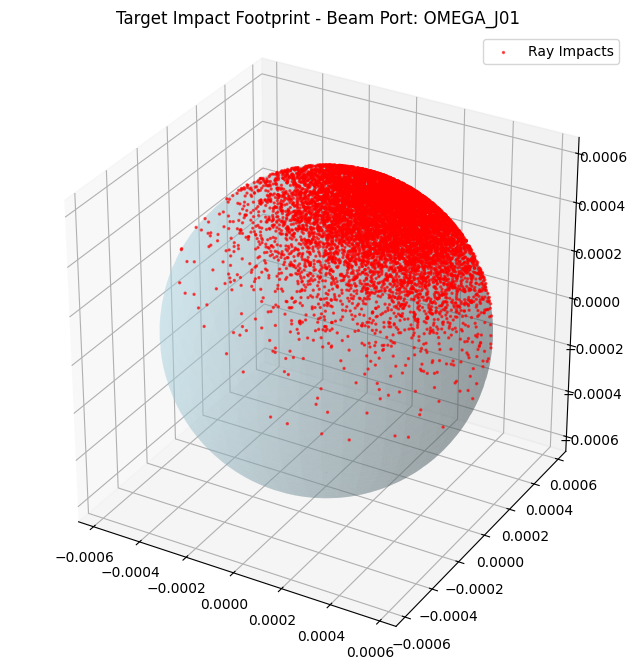

In [748]:
def plot_impact_footprint(impact_df, sphere_radius=TARGET_RADIUS):
    """
    Plots the 3D footprint of a single beam's rays on the target sphere.
    """
    # 1. Create 3D figure and axis
    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 2. Draw the SOLID colored sphere (target)
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = sphere_radius * np.outer(np.cos(u), np.sin(v))
    y_sphere = sphere_radius * np.outer(np.sin(u), np.sin(v))
    z_sphere = sphere_radius * np.outer(np.ones_like(u), np.cos(v))
    
    # Surface plot with transparency to see impacts on both sides
    ax.plot_surface(x_sphere, y_sphere, z_sphere, 
                    color='lightblue', 
                    alpha=0.3,       # Transparency
                    linewidth=0, 
                    antialiased=True)

    # 3. Plot the impact points from the expanded DataFrame
    # Using the columns we just created: xsph_x, xsph_y, xsph_z
    xs = impact_df['xsph_x']
    ys = impact_df['xsph_y']
    zs = impact_df['xsph_z']
    
    # Scatter plot of the 10,000 rays (or as many as hit the target)
    ax.scatter(xs, ys, zs, color='red', s=2, alpha=0.6, label='Ray Impacts')

    # 4. Aesthetic configuration
    beam_id = impact_df['port'].iloc[0] if not impact_df.empty else "N/A"
    ax.set_title(f"Target Impact Footprint - Beam Port: {beam_id}")
    
    # Set axis limits to fit the sphere
    limit = sphere_radius * 1.1
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    
    # Set 1:1:1 aspect ratio so it looks like a sphere, not an egg
    ax.set_box_aspect([1, 1, 1])
    
    plt.legend()
    plt.show()

# --- Execution ---
# We use the expanded view we generated in the previous step
plot_impact_footprint(impact_1window_view, sphere_radius=TARGET_RADIUS)

## Simulation of hits from windows chosen by probability

### Simulation of impacts

In [749]:
def impact_simulated(
    num_beams_to_sample,
    num_samples_per_beam,
    target_radius,
    target_center
 ):
    # 1. USE THE EXPANDED DATAFRAME
    # Using df_beams_vista which already contains 't1_x', 'focus_x', etc.
    beam_df = df_omega.copy() 

    # 2. Probabilities based on energy
    ps = np.array(beam_df['energy'], dtype=float)
    ps /= np.sum(ps)

    # 3. Random beam selection (Monte Carlo)
    list_beams = np.arange(len(beam_df))
    selected_indices = np.random.choice(
        list_beams,
        size=num_beams_to_sample,
        p=ps
    )

    # 4. Impact simulation
    impact_list = []
    for i in selected_indices:
        # Extracting the row for the selected beam
        beam_row = beam_df.iloc[i]
        
        # Calling beam_hit (which in turn calls beam_sample)
        # IMPORTANT: center_target is the argument for the tracing function
        res = beam_hit(
            beam_row,
            num_samples_per_beam,
            radius=target_radius,
            center_target=target_center
        )
        
        if not res.empty:
            # Metadata should already come from beam_hit, but we ensure it here:
            res['port'] = beam_row['port']
            res['subwindow'] = beam_row['subwindow']
            impact_list.append(res)

    if not impact_list:
        print("Warning: No rays hit the target.")
        return pd.DataFrame()

    # 5. Concatenate all impact DataFrames
    impact_df = pd.concat(impact_list, ignore_index=True)

    return impact_df

### Simulation parameters

In [750]:
# Execution
total_impact = impact_simulated(
    num_beams_to_sample=100,
    num_samples_per_beam=1000, 
    target_radius=TARGET_RADIUS,
    target_center=np.array([0.0, 0.0, 0.0])
)

print(f"Simulación masiva completada.")
print(f"Total de impactos registrados: {len(total_impact)}")

Simulación masiva completada.
Total de impactos registrados: 99611


### Information of impacts in dataframe

In [751]:
def impact_df_vista(df_in):
    """
    Helper function to break down vectors in the impact DataFrame.
    """
    df = df_in.copy()
    
    # Function to efficiently expand vector columns
    def expand(df_target, col_name, names):
        if col_name in df_target.columns:
            temp = pd.DataFrame(df_target[col_name].tolist(), index=df_target.index)
            temp.columns = names
            return temp
        return pd.DataFrame()

    # Expand key vectors
    df_x = expand(df, 'x', ['x_x', 'x_y', 'x_z'])
    df_u = expand(df, 'u', ['u_x', 'u_y', 'u_z'])
    df_xsph = expand(df, 'xsph', ['xsph_x', 'xsph_y', 'xsph_z'])
    df_n = expand(df, 'n', ['n_x', 'n_y', 'n_z'])
    
    # Expand spherical coordinates (sph: r, theta, phi)
    df_sph = expand(df, 'sph', ['r', 'theta', 'phi'])

    # Concatenate everything expanded with the original data
    return pd.concat([df.drop(columns=['x', 'u', 'xsph', 'n', 'sph'], errors='ignore'), 
                      df_x, df_u, df_xsph, df_n, df_sph], axis=1)

def preparar_dataframe_impactos(impact_df):
    # 1. Expand vectors and add spherical coordinates
    impact_df = impact_df_vista(impact_df)

    # 2. Ensure port and subwindow columns (avoid KeyErrors)
    if 'port' not in impact_df.columns: 
        impact_df['port'] = 'unknown'
    if 'subwindow' not in impact_df.columns:
        impact_df['subwindow'] = 'unknown'

    # 3. Select relevant columns according to the layout
    cols = [
        'port', 'subwindow', 'l', 'cs', 'theta', 'phi',
        'x_x', 'x_y', 'x_z',
        'u_x', 'u_y', 'u_z',
        'xsph_x', 'xsph_y', 'xsph_z',
        'n_x', 'n_y', 'n_z'
    ]
    available_cols = [c for c in cols if c in impact_df.columns]

    # 4. Round and return final DataFrame
    # Use copy() to avoid SettingWithCopyWarning
    formatted_df = impact_df[available_cols].copy()
    formatted_df = formatted_df.round(4)

    print(f"Valid impacts found: {len(formatted_df)}")
    return formatted_df

# --- Execution ---
df_impactos = preparar_dataframe_impactos(total_impact)
df_impactos

Valid impacts found: 99611


,port,subwindow,l,cs,theta,phi,x_x,x_y,x_z,u_x,u_y,u_z,xsph_x,xsph_y,xsph_z,n_x,n_y,n_z
0,OMEGA_J51,0,1.6498,-0.8674,2.3284,2.0551,-0.2826,-1.1827,-1.1158,0.1714,0.7166,0.6761,0.0002,-0.0004,-0.0004,0.3382,-0.6429,-0.6872
1,OMEGA_J51,0,1.6495,-0.9589,2.0365,1.4650,-0.3104,-1.1944,-1.0954,0.1881,0.7238,0.6639,-0.0001,-0.0005,-0.0003,-0.0943,-0.8885,-0.4491
2,OMEGA_J51,0,1.6502,-0.7351,3.0800,1.1661,-0.3087,-1.1499,-1.1433,0.1871,0.6968,0.6925,-0.0000,-0.0000,-0.0006,-0.0242,-0.0566,-0.9981
3,OMEGA_J51,0,1.6494,-0.9978,2.3752,1.3230,-0.3149,-1.1779,-1.1117,0.1909,0.7139,0.6737,-0.0001,-0.0004,-0.0004,-0.1701,-0.6724,-0.7204
4,OMEGA_J51,0,1.6498,-0.8658,2.5737,0.5492,-0.3362,-1.1584,-1.1264,0.2036,0.7020,0.6824,-0.0003,-0.0002,-0.0005,-0.4588,-0.2808,-0.8430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99606,OMEGA_J53,0,1.6494,-0.9925,2.2770,2.1915,0.8592,-0.8710,-1.1072,-0.5207,0.5278,0.6710,0.0003,-0.0004,-0.0004,0.4425,-0.6189,-0.6489
99607,OMEGA_J53,0,1.6498,-0.8735,2.0309,2.9084,0.8925,-0.8478,-1.0992,-0.5407,0.5138,0.6661,0.0005,-0.0001,-0.0003,0.8717,-0.2071,-0.4441
99608,OMEGA_J53,0,1.6494,-0.9880,2.3976,2.5450,0.8672,-0.8552,-1.1132,-0.5256,0.5183,0.6746,0.0003,-0.0002,-0.0004,0.5602,-0.3805,-0.7358
99609,OMEGA_J53,0,1.6500,-0.8259,1.9015,2.9147,0.8977,-0.8500,-1.0935,-0.5438,0.5151,0.6626,0.0006,-0.0001,-0.0002,0.9216,-0.2128,-0.3247


## Histogram of impacts in a 1m radius sphere

### Divides the sphere in sectors

In [752]:
class SphereSectors():
    def __init__(self, num_theta, num_phi):
      # Create the theta-phi grid edges
      self.theta_edges = np.linspace(0, np.pi, num_theta + 1)  # includes poles
      self.phi_edges = np.linspace(0, 2 * np.pi, num_phi + 1)  # includes closure

      # Coordinates of the spherical sector centers
      self.theta = 0.5 * (self.theta_edges[:-1] + self.theta_edges[1:])
      self.phi = 0.5 * (self.phi_edges[:-1] + self.phi_edges[1:])

      self.mtheta, self.mphi = np.meshgrid(self.theta, self.phi, indexing='ij')       

      return

sectors = SphereSectors( num_theta = 50, num_phi = 50)

### Representation of the mesh

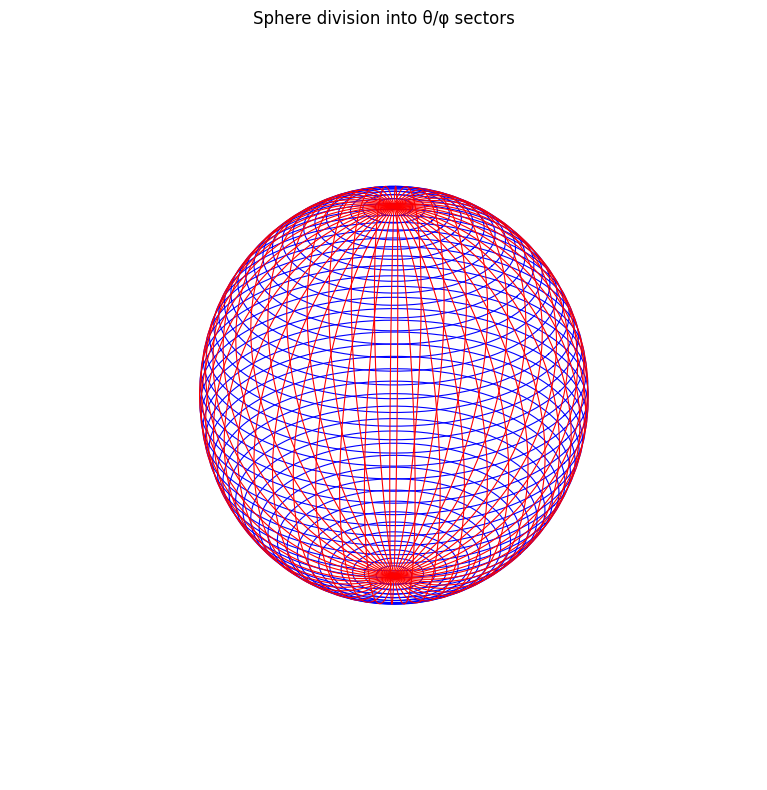

In [753]:
# Parameters
radius = TARGET_RADIUS

# Create 3D figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw horizontal lines (theta)
phi = np.linspace(0, 2 * np.pi, 200)
for theta in sectors.theta:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='blue', linewidth=0.8)

# Draw vertical lines (phi)
theta = np.linspace(0, np.pi, 200)
for phi in sectors.phi:
    x = radius * np.sin(theta) * np.cos(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(theta)
    ax.plot(x, y, z, color='red', linewidth=0.8)

# Aesthetics
ax.set_box_aspect([1, 1, 1])
ax.set_title("Sphere division into θ/φ sectors")
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Function to calculate the area of sectors of the mesh

In [754]:
def spherical_sector_area( theta1, theta2, phi1, phi2, radius=1., ):
    """
    Calculates the surface area of a spherical sector (a cell on the grid)
    defined by theta and phi boundaries.
    """
    # Calculate the area of the spherical zone (ring) between theta1 and theta2
    area_anillo = 2 * np.pi * radius**2 * np.abs(np.cos(theta1) - np.cos(theta2))
    
    # Calculate the longitudinal span
    delta_phi = np.abs(phi2 - phi1)
    
    # The sector area is the fraction of the ring corresponding to delta_phi
    area_sector = (delta_phi / (2 * np.pi)) * area_anillo
    return area_sector

# Calculate the area for all grid cells using broadcasting
sectors.area = spherical_sector_area( 
    sectors.theta_edges[:-1][:,None], 
    sectors.theta_edges[1:][:,None], 
    sectors.phi_edges[:-1][None,:], 
    sectors.phi_edges[1:][None,:], 
    radius=1. 
)

# Verification: the sum of all sector areas must equal the total sphere area (4*pi*r^2)
assert np.isclose( np.sum( sectors.area ), 4.*np.pi, atol=1e-4 ), "The calculated total area does not match the sphere's surface area."

### Plots the centers of each sector in the sphere mesh

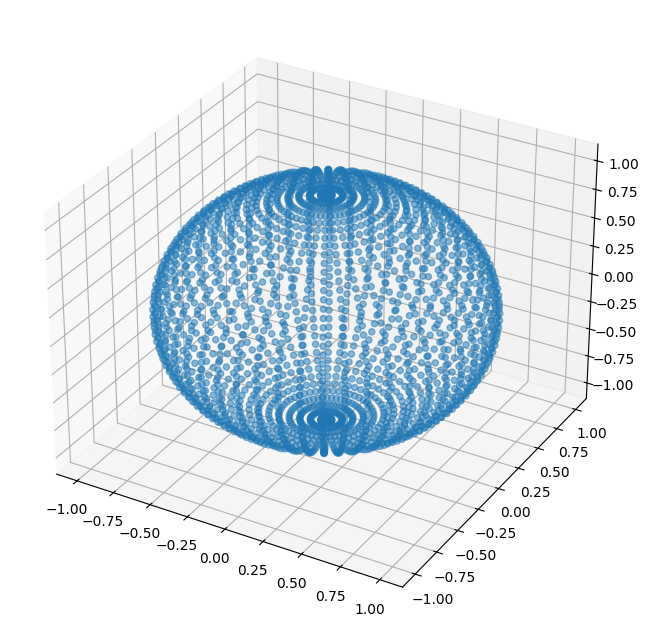

In [755]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection='3d')

xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)
ax.scatter( xs, ys, zs, alpha=0.5)

### Creates energy histogram in sphere

In [756]:
def hist(hits, sectors):
    # 2D Histogram with weights
    hs_raw, _, _ = np.histogram2d(
        hits['theta'],
        hits['phi'],
        bins=[sectors.theta_edges, sectors.phi_edges],
        weights=np.abs(hits['cs'])
    )

    # Density per unit area
    hs = hs_raw / sectors.area

    # Conservation validation
    assert np.isclose(
        np.sum(hs * sectors.area),
        np.sum(np.abs(hits['cs'])),
        atol=1e-4
    ), "The weighted sum does not match the original sum of |cs|."

    # Normalization for visualization
    hs_norm = (hs - np.min(hs)) / (np.max(hs) - np.min(hs))

    # Final DataFrame
    df_hist = pd.DataFrame({
        'theta': sectors.mtheta.ravel(),
        'phi': sectors.mphi.ravel(),
        'hs_raw': hs_raw.ravel(),
        'hs_density': hs.ravel(),
        'hs_norm': hs_norm.ravel()
    })

    return df_hist

In [757]:
hits = df_impactos[df_impactos['cs'] < 0]

In [758]:
df_hist = hist(hits, sectors)

hs = df_hist['hs_density'].values

### Histogram graphic

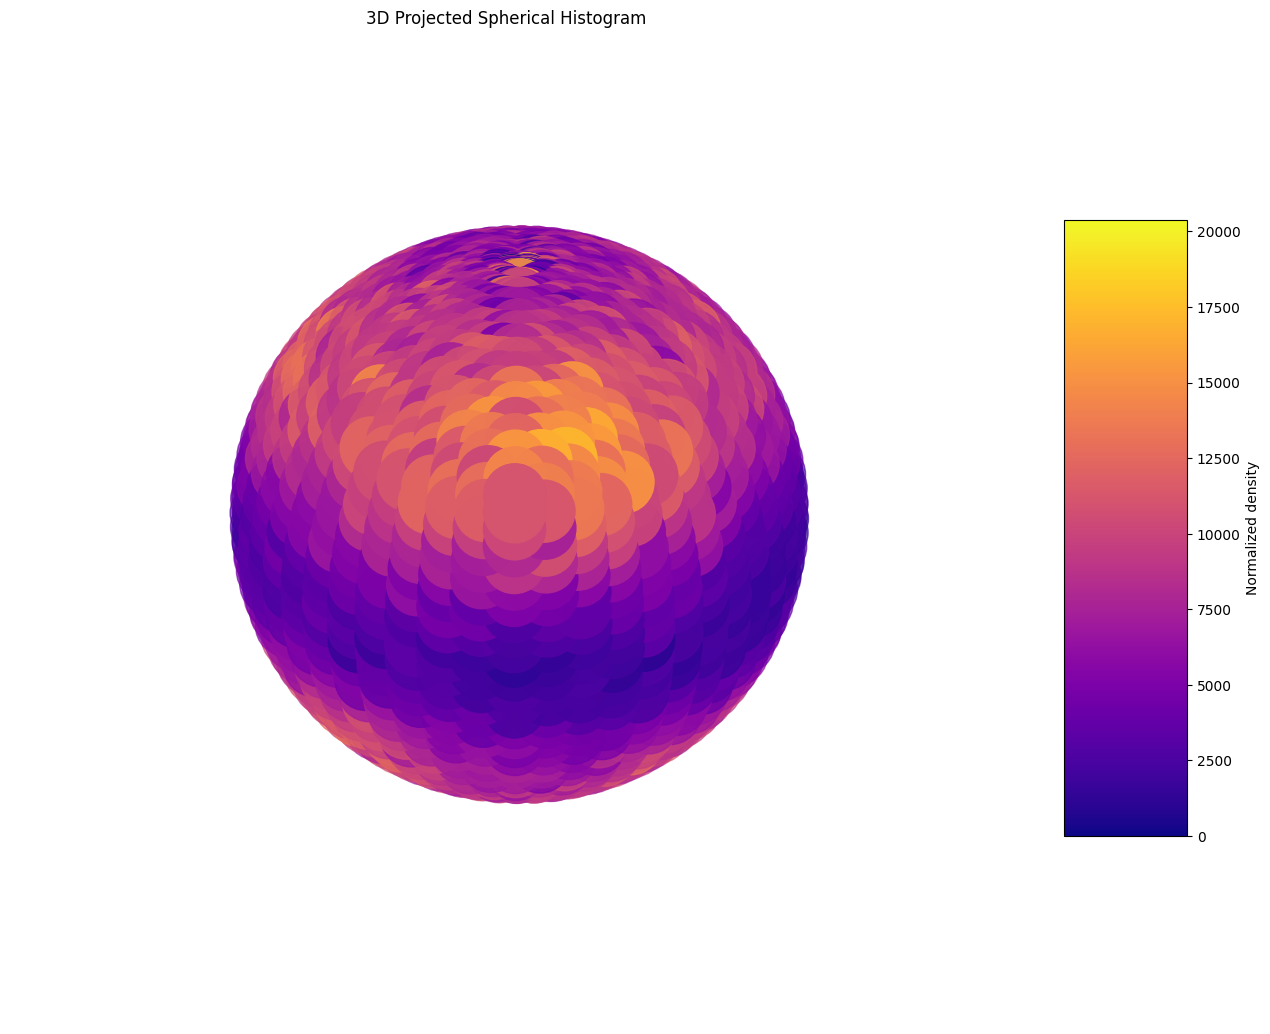

In [759]:
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Convert sector centers to Cartesian coordinates
xs, ys, zs = sph_to_cart(1.0, sectors.mtheta, sectors.mphi)

# Flatten for scatter plot
X = xs.ravel()
Y = ys.ravel()
Z = zs.ravel()
C = hs.ravel()   # hs should be the normalized histogram or density

# Plot
p = ax.scatter(X, Y, Z, c=C, cmap='plasma', s=2000)

# Colorbar
cb = fig.colorbar(p, ax=ax, shrink=0.5, aspect=5)
cb.set_label("Normalized density")

ax.set_box_aspect([1, 1, 1])
ax.set_title("3D Projected Spherical Histogram")
ax.set_axis_off()

plt.show()

### Pyvista histogram graphic

### Import to rwhist file